# RiNALMo PCA fitting + MMD calibration

Replicate the RNA-FM PCA pipeline (`fit_pca.py`) for RiNALMo, then calibrate MMD
thresholds in the PCA-reduced space.

**Part 1**: Fit PCA(16) on RiNALMo embeddings (same protocol as RNA-FM)
**Part 2**: MMD calibration ruler in PCA space (perturbations, indels, shuffles, noise)
**Part 3**: Compare RNA-FM vs RiNALMo thresholds; determine `mean_dist_threshold` + `sw_tau`

In [1]:
import sys, random, gc
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "modules" / "RiNALMo"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "RNA-FM"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "pipeline"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "global_PCA"))

import short_ncrna as sn
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

SEED = 42
random.seed(SEED); np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

Device: mps


In [2]:
# --- Load RiNALMo ---
from rinalmo.pretrained import get_pretrained_model
rin_model, rin_alpha = get_pretrained_model(model_name="giga-v1")
rin_model = rin_model.to(device).eval()

def emb_rinalmo(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    tokens = torch.tensor(
        rin_alpha.batch_tokenize([rna]), dtype=torch.int64, device=device
    )
    with torch.no_grad():
        out = rin_model(tokens)
    return out["representation"][0, 1:1 + len(rna), :].cpu().float().numpy()

EMB_DIM = 1280
print(f"RiNALMo ready, emb dim = {EMB_DIM}")

RiNALMo ready, emb dim = 1280


## Part 1: Fit PCA on RiNALMo embeddings

Same protocol as `fit_pca.py`:
- 30% genomic noise (intergenic), 70% ncRNA windows
- Window sizes: 48-256 nt
- Scaled to ~10k embeddings for MacBook; increase `TARGET_EMBEDDINGS` on GPU

In [3]:
# --- Parameters (matching fit_pca.py) ---
N_PCA_COMPONENTS = 16
TARGET_EMBEDDINGS = 10_000  # 10k for MacBook; set to 100_000 on GPU
NOISE_RATIO = 0.3
WINDOW_SIZES = [48, 64, 80, 96, 128, 160, 192, 224, 256]
NCRNA_BIOTYPES = {"tRNA", "snoRNA", "miRNA", "snRNA", "misc_RNA", "scaRNA", "lncRNA"}

# --- Load reference data ---
BED_PATH    = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.input.w.tRNA.bed"
TWOBIT_PATH = REPO_ROOT / "input_data" / "2bit" / "hg38.2bit"
META_PATH   = REPO_ROOT / "input_data" / "reference_annotation" / "test_sample.metadata.tsv"

accessor = TwoBitAccessor(str(TWOBIT_PATH))
bed_data = read_bed12_file(str(BED_PATH))
meta_df  = pd.read_csv(META_PATH, sep="\t")
biotype_map = dict(zip(meta_df["transcript_id"], meta_df["transcript_biotype"]))

# Build biotype lookup including tRNAs
def get_biotype(tid):
    if tid.startswith("tRNA-") and "Und-NNN" not in tid:
        return "tRNA"
    return biotype_map.get(tid.split(".")[0])

print(f"Loaded {len(bed_data)} transcripts")
print(f"Target: {TARGET_EMBEDDINGS:,} position-level embeddings")
print(f"  Noise: {int(TARGET_EMBEDDINGS * NOISE_RATIO):,}")
print(f"  ncRNA: {TARGET_EMBEDDINGS - int(TARGET_EMBEDDINGS * NOISE_RATIO):,}")

Loaded 386300 transcripts
Target: 10,000 position-level embeddings
  Noise: 3,000
  ncRNA: 7,000


In [4]:
# --- Collect genomic noise windows ---
chrom_sizes = {}
for i in list(range(1, 23)) + ["X", "Y"]:
    chrom_sizes[f"chr{i}"] = 200_000_000  # approximate; sufficient for sampling

chroms = [c for c in chrom_sizes if c.startswith("chr") and "_" not in c and c != "chrM"]
rng = random.Random(SEED)

n_noise_windows = int(TARGET_EMBEDDINGS * NOISE_RATIO) // np.mean(WINDOW_SIZES).astype(int)
# We need enough windows so that total positions >= n_noise_target
n_noise_target = int(TARGET_EMBEDDINGS * NOISE_RATIO)

noise_windows = []
noise_positions = 0
attempts = 0
while noise_positions < n_noise_target and attempts < n_noise_target * 5:
    attempts += 1
    chrom = rng.choice(chroms)
    ws = rng.choice(WINDOW_SIZES)
    start = rng.randint(0, chrom_sizes[chrom] - ws)
    try:
        seq = str(accessor.fetch(chrom, start, start + ws)).upper().replace("T", "U")
        if "N" not in seq and len(seq) == ws:
            noise_windows.append(seq)
            noise_positions += ws
    except:
        continue

print(f"Noise windows: {len(noise_windows)} ({noise_positions:,} positions)")

Noise windows: 22 (3,168 positions)


In [5]:
# --- Collect ncRNA windows ---
n_ncrna_target = TARGET_EMBEDDINGS - int(TARGET_EMBEDDINGS * NOISE_RATIO)

# Group transcripts by biotype
by_biotype = {}
for t in bed_data:
    bt = get_biotype(t.id)
    if bt in NCRNA_BIOTYPES:
        by_biotype.setdefault(bt, []).append(t)

print("ncRNA transcripts by biotype:")
for bt, tlist in sorted(by_biotype.items(), key=lambda x: -len(x[1])):
    print(f"  {bt}: {len(tlist)}")

ncrna_windows = []
ncrna_positions = 0
max_windows_per_tx = 5

rng_ncrna = random.Random(SEED)
for bt, tlist in by_biotype.items():
    rng_ncrna.shuffle(tlist)
    for t in tlist:
        if ncrna_positions >= n_ncrna_target:
            break
        seq = sn._get_spliced_sequence(t, accessor)
        if not seq or "N" in seq.upper() or len(seq) < min(WINDOW_SIZES):
            continue
        seq = seq.upper().replace("T", "U")
        # Sliding windows, same as fit_pca.py
        n_taken = 0
        for ws in WINDOW_SIZES:
            if len(seq) < ws:
                continue
            step = max(1, (len(seq) - ws) // max_windows_per_tx)
            for start in range(0, len(seq) - ws + 1, step):
                ncrna_windows.append(seq[start:start + ws])
                ncrna_positions += ws
                n_taken += 1
                if n_taken >= max_windows_per_tx:
                    break
            if n_taken >= max_windows_per_tx:
                break
    if ncrna_positions >= n_ncrna_target:
        break

print(f"\nncRNA windows: {len(ncrna_windows)} ({ncrna_positions:,} positions)")
print(f"Total windows: {len(noise_windows) + len(ncrna_windows)}")
print(f"Total positions: {noise_positions + ncrna_positions:,}")

ncRNA transcripts by biotype:
  tRNA: 582
  miRNA: 126
  lncRNA: 106
  snoRNA: 39

ncRNA windows: 150 (7,200 positions)
Total windows: 172
Total positions: 10,368


In [6]:
# --- Embed all windows with RiNALMo ---
all_windows = noise_windows + ncrna_windows
rng_shuffle = random.Random(SEED)
rng_shuffle.shuffle(all_windows)

print(f"Embedding {len(all_windows)} windows with RiNALMo...")
all_chunks = []
for i, seq in enumerate(all_windows):
    all_chunks.append(emb_rinalmo(seq))
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(all_windows)} ({sum(c.shape[0] for c in all_chunks):,} positions)")
        gc.collect()

# Stack all position-level embeddings
X = np.vstack(all_chunks).astype(np.float32)
print(f"\nEmbedding matrix: {X.shape}  ({X.shape[0]:,} positions x {X.shape[1]} dim)")
del all_chunks; gc.collect()

Embedding 172 windows with RiNALMo...
  50/172 (2,816 positions)
  100/172 (5,984 positions)
  150/172 (9,152 positions)

Embedding matrix: (10368, 1280)  (10,368 positions x 1280 dim)


3630

In [7]:
# --- Fit PCA ---
MAX_K = 64
pca_full = PCA(n_components=min(MAX_K, X.shape[1])).fit(X)
pca_16 = PCA(n_components=N_PCA_COMPONENTS).fit(X)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"RiNALMo PCA on {X.shape[0]:,} position embeddings ({X.shape[1]}-dim)")
print(f"\nExplained variance ratio (first 16 PCs):")
for i, var in enumerate(pca_16.explained_variance_ratio_, 1):
    print(f"  PC{i:2d}: {var:.4f} ({var*100:.2f}%)")
print(f"\nCumulative:")
print(f"  PC1-8:  {cum_var[7]:.4f} ({cum_var[7]*100:.2f}%)")
print(f"  PC1-16: {cum_var[15]:.4f} ({cum_var[15]*100:.2f}%)")
print(f"  PC1-32: {cum_var[31]:.4f} ({cum_var[31]*100:.2f}%)")

# Compare with RNA-FM
try:
    rnafm_pca = np.load(REPO_ROOT / "modules" / "global_PCA" / "rnafm_pca_k16.npz")
    rnafm_var = rnafm_pca["explained_variance_ratio"]
    print(f"\nRNA-FM PCA(16) cumulative: {rnafm_var.sum():.4f} ({rnafm_var.sum()*100:.2f}%)")
    print(f"RiNALMo PCA(16) cumulative: {cum_var[15]:.4f} ({cum_var[15]*100:.2f}%)")
except:
    print("\n(RNA-FM PCA file not found for comparison)")

RiNALMo PCA on 10,368 position embeddings (1280-dim)

Explained variance ratio (first 16 PCs):
  PC 1: 0.0886 (8.86%)
  PC 2: 0.0832 (8.32%)
  PC 3: 0.0753 (7.53%)
  PC 4: 0.0345 (3.45%)
  PC 5: 0.0294 (2.94%)
  PC 6: 0.0261 (2.61%)
  PC 7: 0.0259 (2.59%)
  PC 8: 0.0234 (2.34%)
  PC 9: 0.0203 (2.03%)
  PC10: 0.0166 (1.66%)
  PC11: 0.0162 (1.62%)
  PC12: 0.0135 (1.35%)
  PC13: 0.0127 (1.27%)
  PC14: 0.0119 (1.19%)
  PC15: 0.0118 (1.18%)
  PC16: 0.0111 (1.11%)

Cumulative:
  PC1-8:  0.3865 (38.65%)
  PC1-16: 0.5006 (50.06%)
  PC1-32: 0.6190 (61.90%)

RNA-FM PCA(16) cumulative: 0.8536 (85.36%)
RiNALMo PCA(16) cumulative: 0.5006 (50.06%)


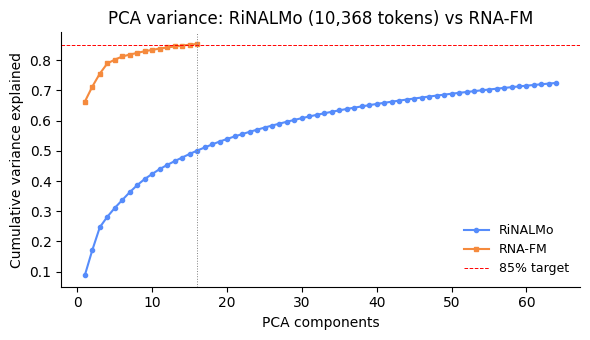

In [8]:
# --- Variance explained plot ---
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, marker="o", ms=3, label="RiNALMo")

try:
    # Overlay RNA-FM curve (only 16 PCs available)
    rnafm_cum = np.cumsum(rnafm_var)
    ax.plot(np.arange(1, len(rnafm_cum) + 1), rnafm_cum, marker="s", ms=3,
            label="RNA-FM", color="C1")
except:
    pass

ax.axhline(0.85, color="red", lw=0.7, ls="--", label="85% target")
ax.axvline(16, color="grey", lw=0.7, ls=":")
ax.set_xlabel("PCA components")
ax.set_ylabel("Cumulative variance explained")
ax.set_title(f"PCA variance: RiNALMo ({X.shape[0]:,} tokens) vs RNA-FM")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

In [9]:
# --- Save PCA model (same format as rnafm_pca_k16.npz) ---
output_path = REPO_ROOT / "modules" / "global_PCA" / "rinalmo_pca_k16.npz"

np.savez_compressed(
    output_path,
    mean=pca_16.mean_,
    components=pca_16.components_,
    explained_variance=pca_16.explained_variance_,
    explained_variance_ratio=pca_16.explained_variance_ratio_,
    n_components=N_PCA_COMPONENTS,
    n_samples=X.shape[0],
    input_dim=X.shape[1],
)

import os
print(f"Saved to {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")

# Verify it loads correctly with the existing interface
from apply_pca import load_pca
pca_loaded = load_pca(output_path)
print(f"Loaded: {pca_loaded['n_components']} components, "
      f"var={pca_loaded['explained_variance_ratio'].sum():.4f}")

Saved to /Users/Bogdan.Kirilenko/Developer/CURIA_pipeline/modules/global_PCA/rinalmo_pca_k16.npz
File size: 80.5 KB
Loaded: 16 components, var=0.5006


## Part 2: MMD calibration in PCA-reduced RiNALMo space

Same experiments as `rinalmo_mmd_calibration.ipynb`, but now:
`embed → PCA(16) → compute MMD`

This matches how the pipeline actually uses embeddings.

In [10]:
# --- Helper: embed + PCA-reduce ---
def emb_pca(seq: str) -> np.ndarray:
    """Embed with RiNALMo, then project to PCA(16). Returns (L, 16)."""
    raw = emb_rinalmo(seq)
    centered = raw - pca_16.mean_
    return (centered @ pca_16.components_.T).astype(np.float32)

def mmd_pca(a_seq: str, b_seq: str) -> float:
    return sn._compute_mmd(emb_pca(a_seq), emb_pca(b_seq))

# --- Reference sequences ---
TARGETS = {
    "tRNA-Asn-GTT-chr1-140": "tRNA (74 nt)",
    "ENST00000362168.1": "miRNA (110 nt)",
    "ENST00000383885.1": "snoRNA (135 nt)",
}

ref_seqs = {}
for tid, label in TARGETS.items():
    for t in bed_data:
        if t.id == tid:
            seq = sn._get_spliced_sequence(t, accessor).upper().replace("T", "U")
            ref_seqs[label] = seq
            print(f"  {label}: {len(seq)} nt")
            break

# Genomic noise windows for baselines
rng_noise = random.Random(SEED + 99)
noise_seqs = []
while len(noise_seqs) < 30:
    chrom = rng_noise.choice(chroms)
    start = rng_noise.randint(0, chrom_sizes[chrom] - 100)
    try:
        seq = str(accessor.fetch(chrom, start, start + 74)).upper().replace("T", "U")
        if "N" not in seq:
            noise_seqs.append(seq)
    except:
        continue
print(f"\nNoise windows: {len(noise_seqs)}")

  tRNA (74 nt): 74 nt
  miRNA (110 nt): 110 nt
  snoRNA (135 nt): 135 nt

Noise windows: 30


In [11]:
# --- Perturbation experiments ---
BASES = "AUGC"

def point_mutate(seq, frac, rng):
    s = list(seq)
    n = max(1, int(round(frac * len(s))))
    for i in rng.sample(range(len(s)), n):
        s[i] = rng.choice([b for b in BASES if b != s[i]])
    return "".join(s)

def insert_at(seq, pos, n, rng):
    return seq[:pos] + "".join(rng.choices(BASES, k=n)) + seq[pos:]

def delete_at(seq, pos, n):
    return seq[:pos] + seq[pos+n:]

def shift_seq(seq, n):
    rng_s = random.Random(42)
    tail = "".join(rng_s.choices(BASES, k=abs(n)))
    return seq[n:] + tail if n > 0 else tail + seq[:n]

def shuffled(seq, rng):
    s = list(seq); rng.shuffle(s); return "".join(s)

def random_seq(length, rng):
    return "".join(rng.choices(BASES, k=length))

N_REP = 10
rng = random.Random(SEED)

cal_rows = []
for label, seq in ref_seqs.items():
    L = len(seq)
    ref_e = emb_pca(seq)
    print(f"\n=== {label} ({L} nt) ===")

    cal_rows.append({"ref": label, "condition": "identical", "mmd": 0.0})

    # Point mutations
    for frac in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
        n_mut = max(1, int(round(frac * L)))
        for _ in range(N_REP):
            mut = point_mutate(seq, frac, rng)
            cal_rows.append({"ref": label, "condition": f"mut_{int(frac*100)}%",
                             "mmd": sn._compute_mmd(ref_e, emb_pca(mut))})
        print(f"  mut {int(frac*100)}% ({n_mut} nt): done")

    # Insertions
    for ins_len in [1, 2, 5, 10, 20]:
        for _ in range(N_REP):
            pos = rng.randint(0, L)
            cal_rows.append({"ref": label, "condition": f"ins_{ins_len}",
                             "mmd": sn._compute_mmd(ref_e, emb_pca(insert_at(seq, pos, ins_len, rng)))})
        print(f"  ins +{ins_len} nt: done")

    # Deletions
    for del_len in [1, 2, 5, 10, 20]:
        if del_len >= L:
            continue
        for _ in range(N_REP):
            pos = rng.randint(0, L - del_len)
            cal_rows.append({"ref": label, "condition": f"del_{del_len}",
                             "mmd": sn._compute_mmd(ref_e, emb_pca(delete_at(seq, pos, del_len)))})
        print(f"  del -{del_len} nt: done")

    # Shifts
    for shift in [1, 2, 5, 10, 20]:
        for _ in range(N_REP):
            cal_rows.append({"ref": label, "condition": f"shift_{shift}",
                             "mmd": sn._compute_mmd(ref_e, emb_pca(shift_seq(seq, shift)))})
        print(f"  shift +{shift} nt: done")

    # Shuffled
    for _ in range(N_REP):
        cal_rows.append({"ref": label, "condition": "shuffled",
                         "mmd": sn._compute_mmd(ref_e, emb_pca(shuffled(seq, rng)))})
    print(f"  shuffled: done")

    # Random AUGC
    for _ in range(N_REP):
        cal_rows.append({"ref": label, "condition": "random",
                         "mmd": sn._compute_mmd(ref_e, emb_pca(random_seq(L, rng)))})
    print(f"  random: done")

    # Genomic noise
    for ns in noise_seqs[:N_REP]:
        ns_adj = ns[:L] if len(ns) >= L else ns + random_seq(L - len(ns), rng)
        cal_rows.append({"ref": label, "condition": "genomic_noise",
                         "mmd": sn._compute_mmd(ref_e, emb_pca(ns_adj))})
    print(f"  genomic noise: done")

cal_df = pd.DataFrame(cal_rows)
print(f"\nTotal measurements: {len(cal_df)}")


=== tRNA (74 nt) (74 nt) ===
  mut 1% (1 nt): done
  mut 2% (1 nt): done
  mut 5% (4 nt): done
  mut 10% (7 nt): done
  mut 15% (11 nt): done
  mut 20% (15 nt): done
  mut 30% (22 nt): done
  mut 50% (37 nt): done
  ins +1 nt: done
  ins +2 nt: done
  ins +5 nt: done
  ins +10 nt: done
  ins +20 nt: done
  del -1 nt: done
  del -2 nt: done
  del -5 nt: done
  del -10 nt: done
  del -20 nt: done
  shift +1 nt: done
  shift +2 nt: done
  shift +5 nt: done
  shift +10 nt: done
  shift +20 nt: done
  shuffled: done
  random: done
  genomic noise: done

=== miRNA (110 nt) (110 nt) ===
  mut 1% (1 nt): done
  mut 2% (2 nt): done
  mut 5% (6 nt): done
  mut 10% (11 nt): done
  mut 15% (16 nt): done
  mut 20% (22 nt): done
  mut 30% (33 nt): done
  mut 50% (55 nt): done
  ins +1 nt: done
  ins +2 nt: done
  ins +5 nt: done
  ins +10 nt: done
  ins +20 nt: done
  del -1 nt: done
  del -2 nt: done
  del -5 nt: done
  del -10 nt: done
  del -20 nt: done
  shift +1 nt: done
  shift +2 nt: done
  

In [12]:
# --- RiNALMo PCA(16) MMD Ruler ---
print("=" * 70)
print("RINALMO PCA(16) MMD RULER")
print("=" * 70)

def mmd_range(df, condition):
    vals = df[df.condition == condition]["mmd"]
    return f"{vals.mean():.4f} (\u00b1{vals.std():.4f})"

print(f"\n{'Condition':>20s}  {'Mean MMD (\u00b1std)':>20s}  Interpretation")
print("-" * 75)
print(f"{'identical':>20s}  {'0.0000':>20s}  Perfect match")

for cond, interp in [
    ("mut_1%", "~1 nt change"),
    ("mut_2%", "~2 nt changes"),
    ("mut_5%", "~4-7 nt changes"),
    ("mut_10%", "~7-14 nt changes"),
    ("mut_15%", "~11-20 nt changes"),
    ("mut_20%", "~15-27 nt changes"),
    ("mut_30%", "heavily mutated"),
    ("mut_50%", "half the sequence changed"),
    ("ins_1", "+1 nt insertion"),
    ("ins_5", "+5 nt insertion"),
    ("ins_10", "+10 nt insertion"),
    ("ins_20", "+20 nt insertion"),
    ("del_1", "-1 nt deletion"),
    ("del_5", "-5 nt deletion"),
    ("del_10", "-10 nt deletion"),
    ("del_20", "-20 nt deletion"),
    ("shift_1", "1 nt boundary shift"),
    ("shift_5", "5 nt boundary shift"),
    ("shift_10", "10 nt boundary shift"),
    ("shift_20", "20 nt boundary shift"),
    ("shuffled", "same composition, no structure"),
    ("random", "random AUGC"),
    ("genomic_noise", "real intergenic sequence"),
]:
    if cond in cal_df["condition"].values:
        print(f"{cond:>20s}  {mmd_range(cal_df, cond):>20s}  {interp}")

RINALMO PCA(16) MMD RULER

           Condition       Mean MMD (±std)  Interpretation
---------------------------------------------------------------------------
           identical                0.0000  Perfect match
              mut_1%      0.0000 (±0.0000)  ~1 nt change
              mut_2%      0.0000 (±0.0000)  ~2 nt changes
              mut_5%      0.0058 (±0.0198)  ~4-7 nt changes
             mut_10%      0.0197 (±0.0308)  ~7-14 nt changes
             mut_15%      0.0652 (±0.0345)  ~11-20 nt changes
             mut_20%      0.1083 (±0.0413)  ~15-27 nt changes
             mut_30%      0.1710 (±0.0509)  heavily mutated
             mut_50%      0.2304 (±0.0575)  half the sequence changed
               ins_1      0.0000 (±0.0000)  +1 nt insertion
               ins_5      0.0000 (±0.0000)  +5 nt insertion
              ins_10      0.0020 (±0.0107)  +10 nt insertion
              ins_20      0.0172 (±0.0270)  +20 nt insertion
               del_1      0.0000 (±0.0000)  -1 n

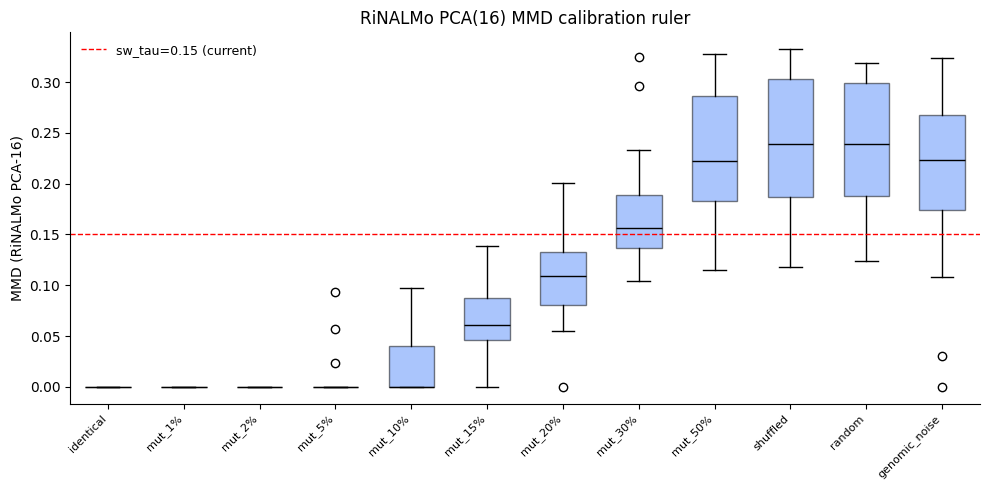

In [13]:
# --- Calibration plot ---
condition_order = [
    "identical", "mut_1%", "mut_2%", "mut_5%", "mut_10%", "mut_15%",
    "mut_20%", "mut_30%", "mut_50%", "shuffled", "random", "genomic_noise",
]

fig, ax = plt.subplots(figsize=(10, 5))
positions = []
for i, cond in enumerate(condition_order):
    vals = cal_df[cal_df.condition == cond]["mmd"]
    if len(vals) == 0:
        continue
    bp = ax.boxplot([vals], positions=[i], widths=0.6, patch_artist=True,
                    boxprops=dict(facecolor="C0", alpha=0.5),
                    medianprops=dict(color="black"))
    positions.append(i)

ax.set_xticks(range(len(condition_order)))
ax.set_xticklabels(condition_order, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("MMD (RiNALMo PCA-16)")
ax.set_title("RiNALMo PCA(16) MMD calibration ruler")
ax.axhline(0.15, color="red", lw=1, ls="--", label="sw_tau=0.15 (current)")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## Part 3: Threshold comparison

1. Panel-B: tRNA copies + miRNA distractor — centroid distances in PCA space
2. `sw_tau=0.15` mapping: where does the RNA-FM threshold land on the RiNALMo scale?
3. `mean_dist_threshold`: what value works for RiNALMo PCA?

In [14]:
# --- Panel-B: PCA centroid distances ---
PANEL_B = {
    "tRNA-Asn-GTT-chr1-140": {"color": "#1a3a5c", "label": "tRNA-Asn (copy 1)"},
    "tRNA-Asn-GTT-chr1-139": {"color": "#6baed6", "label": "tRNA-Asn (copy 2)"},
    "ENST00000362168.1":     {"color": "#e8720c", "label": "miRNA (MIR103A1)"},
}

panel_b_seqs = {}
for t in bed_data:
    if t.id in PANEL_B:
        s = sn._get_spliced_sequence(t, accessor).upper().replace("T", "U")
        panel_b_seqs[t.id] = s

# Embed + PCA
panel_pca_embs = {tid: emb_pca(s) for tid, s in panel_b_seqs.items()}

# MMD in PCA space
print("Panel-B MMD in RiNALMo PCA(16) space:")
keys = list(panel_b_seqs.keys())
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        m = sn._compute_mmd(panel_pca_embs[keys[i]], panel_pca_embs[keys[j]])
        print(f"  {PANEL_B[keys[i]]['label']:>20s} vs {PANEL_B[keys[j]]['label']:<20s}: MMD={m:.4f}")

# Centroid distances
print("\nPCA centroid distances (L2):")
centroids = {tid: e.mean(axis=0) for tid, e in panel_pca_embs.items()}
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        d = np.linalg.norm(centroids[keys[i]] - centroids[keys[j]])
        print(f"  {PANEL_B[keys[i]]['label']:>20s} vs {PANEL_B[keys[j]]['label']:<20s}: dist={d:.2f}")

# Also compute with RNA-FM PCA for comparison
try:
    import fm
    fm_model, fm_alpha = fm.pretrained.rna_fm_t12()
    fm_model.eval().to(device)
    fm_bc = fm_alpha.get_batch_converter()

    def emb_rnafm_pca(seq):
        rna = seq.upper().replace("T", "U")
        _, _, tk = fm_bc([("x", rna)])
        tk = tk.to(device)
        with torch.no_grad():
            out = fm_model(tk, repr_layers=[12])["representations"][12]
        raw = out[0, 1:1 + len(rna), :].cpu().float().numpy()
        centered = raw - rnafm_pca["mean"]
        return (centered @ rnafm_pca["components"].T).astype(np.float32)

    print("\nRNA-FM PCA(16) centroid distances for comparison:")
    fm_centroids = {tid: emb_rnafm_pca(s).mean(axis=0) for tid, s in panel_b_seqs.items()}
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            d = np.linalg.norm(fm_centroids[keys[i]] - fm_centroids[keys[j]])
            print(f"  {PANEL_B[keys[i]]['label']:>20s} vs {PANEL_B[keys[j]]['label']:<20s}: dist={d:.2f}")
except Exception as e:
    print(f"\n(RNA-FM comparison skipped: {e})")

Panel-B MMD in RiNALMo PCA(16) space:
      miRNA (MIR103A1) vs tRNA-Asn (copy 1)   : MMD=0.2226
      miRNA (MIR103A1) vs tRNA-Asn (copy 2)   : MMD=0.2366
     tRNA-Asn (copy 1) vs tRNA-Asn (copy 2)   : MMD=0.0000

PCA centroid distances (L2):
      miRNA (MIR103A1) vs tRNA-Asn (copy 1)   : dist=16.91
      miRNA (MIR103A1) vs tRNA-Asn (copy 2)   : dist=18.56
     tRNA-Asn (copy 1) vs tRNA-Asn (copy 2)   : dist=2.35

RNA-FM PCA(16) centroid distances for comparison:
      miRNA (MIR103A1) vs tRNA-Asn (copy 1)   : dist=2.68
      miRNA (MIR103A1) vs tRNA-Asn (copy 2)   : dist=2.32
     tRNA-Asn (copy 1) vs tRNA-Asn (copy 2)   : dist=0.74


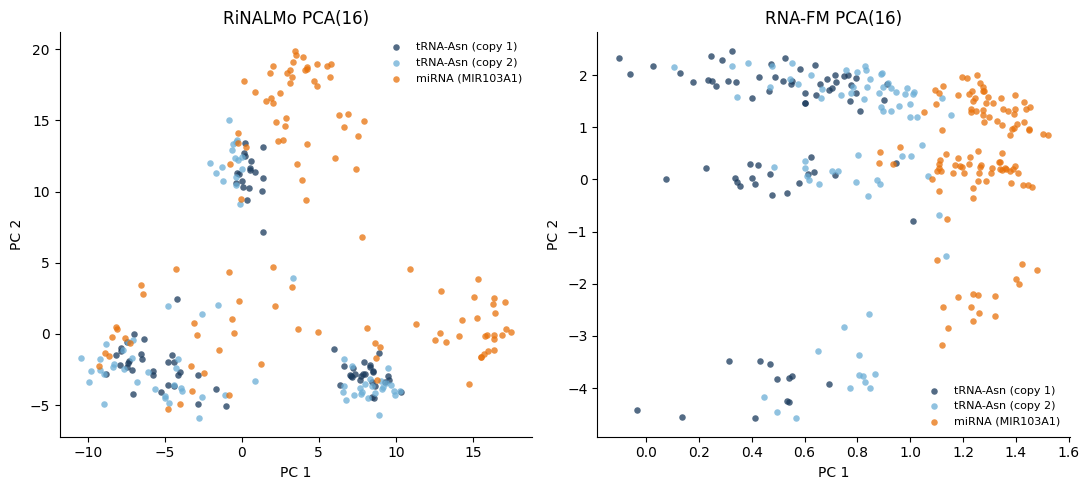

In [15]:
# --- PC1/PC2 scatter: Panel-B in RiNALMo PCA space ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax_idx, (title, embs) in enumerate([
    ("RiNALMo PCA(16)", panel_pca_embs),
    ("RNA-FM PCA(16)", {tid: emb_rnafm_pca(s) for tid, s in panel_b_seqs.items()} if 'emb_rnafm_pca' in dir() else None),
]):
    ax = axes[ax_idx]
    if embs is None:
        ax.text(0.5, 0.5, "RNA-FM not loaded", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        continue
    for tid, meta in PANEL_B.items():
        p = embs[tid]
        ax.scatter(p[:, 0], p[:, 1], c=meta["color"], label=meta["label"],
                   s=22, alpha=0.75, linewidths=0, zorder=3)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.set_title(title)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

plt.tight_layout(); plt.show()

In [16]:
# --- sw_tau mapping + mean_dist_threshold recommendation ---
print("=" * 70)
print("THRESHOLD RECOMMENDATIONS")
print("=" * 70)

# Where does sw_tau=0.15 sit on the RiNALMo PCA ruler?
for cond in ["mut_10%", "mut_15%", "mut_20%", "mut_30%", "shuffled", "random", "genomic_noise"]:
    vals = cal_df[cal_df.condition == cond]["mmd"]
    if len(vals) > 0:
        frac_below = (vals < 0.15).mean()
        print(f"  {cond:>15s}: mean={vals.mean():.4f}, frac < 0.15 = {frac_below:.0%}")

print("\n--- sw_tau analysis ---")
noise_mmds = cal_df[cal_df.condition.isin(["shuffled", "random", "genomic_noise"])]["mmd"]
signal_mmds = cal_df[cal_df.condition.isin(["mut_5%", "mut_10%", "mut_15%"])]["mmd"]

print(f"Signal (mut 5-15%) range: {signal_mmds.min():.4f} - {signal_mmds.max():.4f} (mean {signal_mmds.mean():.4f})")
print(f"Noise (shuffled/random) range: {noise_mmds.min():.4f} - {noise_mmds.max():.4f} (mean {noise_mmds.mean():.4f})")

# Suggested tau: midpoint between worst signal and best noise
if len(signal_mmds) > 0 and len(noise_mmds) > 0:
    gap_lo = signal_mmds.quantile(0.95)  # 95th percentile of signal
    gap_hi = noise_mmds.quantile(0.05)   # 5th percentile of noise
    suggested_tau = (gap_lo + gap_hi) / 2
    print(f"\n95th-pct signal: {gap_lo:.4f}")
    print(f" 5th-pct noise:  {gap_hi:.4f}")
    print(f"Suggested sw_tau: {suggested_tau:.4f}")
    print(f"Current sw_tau (RNA-FM): 0.15")
    print(f"Ratio: {suggested_tau / 0.15:.2f}x")

print("\n--- mean_dist_threshold analysis ---")
print("PCA centroid distances:")
tRNA_copy_dist = np.linalg.norm(centroids[keys[0]] - centroids[keys[1]])
miRNA_dist_0 = np.linalg.norm(centroids[keys[0]] - centroids[keys[2]])
miRNA_dist_1 = np.linalg.norm(centroids[keys[1]] - centroids[keys[2]])
print(f"  tRNA copy1 vs copy2:  {tRNA_copy_dist:.2f} (should be BELOW threshold)")
print(f"  tRNA vs miRNA:        {miRNA_dist_0:.2f}, {miRNA_dist_1:.2f} (should be ABOVE threshold)")
print(f"\nCurrent RNA-FM threshold: 3.0")
if tRNA_copy_dist > 0:
    # Threshold should be above the copy distance but below the cross-type distance
    suggested_thresh = (tRNA_copy_dist + min(miRNA_dist_0, miRNA_dist_1)) / 2
    print(f"Suggested mean_dist_threshold: {suggested_thresh:.1f}")
    print(f"  (midpoint between within-class {tRNA_copy_dist:.2f} and between-class {min(miRNA_dist_0, miRNA_dist_1):.2f})")

THRESHOLD RECOMMENDATIONS
          mut_10%: mean=0.0197, frac < 0.15 = 100%
          mut_15%: mean=0.0652, frac < 0.15 = 100%
          mut_20%: mean=0.1083, frac < 0.15 = 90%
          mut_30%: mean=0.1710, frac < 0.15 = 30%
         shuffled: mean=0.2383, frac < 0.15 = 7%
           random: mean=0.2404, frac < 0.15 = 3%
    genomic_noise: mean=0.2097, frac < 0.15 = 20%

--- sw_tau analysis ---
Signal (mut 5-15%) range: 0.0000 - 0.1390 (mean 0.0302)
Noise (shuffled/random) range: 0.0000 - 0.3324 (mean 0.2294)

95th-pct signal: 0.1069
 5th-pct noise:  0.1209
Suggested sw_tau: 0.1139
Current sw_tau (RNA-FM): 0.15
Ratio: 0.76x

--- mean_dist_threshold analysis ---
PCA centroid distances:
  tRNA copy1 vs copy2:  16.91 (should be BELOW threshold)
  tRNA vs miRNA:        18.56, 2.35 (should be ABOVE threshold)

Current RNA-FM threshold: 3.0
Suggested mean_dist_threshold: 9.6
  (midpoint between within-class 16.91 and between-class 2.35)


## Summary

In [18]:
print("=" * 70)
print("SUMMARY: RNA-FM vs RiNALMo in PCA(16) space")
print("=" * 70)

print(f"\n1. PCA variance explained at k=16:")
print(f"   RiNALMo: {cum_var[15]:.4f} ({cum_var[15]*100:.1f}%)")
try:
    print(f"   RNA-FM:  {rnafm_var.sum():.4f} ({rnafm_var.sum()*100:.1f}%)")
except:
    pass

print(f"\n2. MMD ruler comparison (PCA-16 space):")
print(f"   {'Condition':>20s}  {'RiNALMo PCA':>15s}")
for cond in ["mut_5%", "mut_10%", "mut_20%", "mut_50%", "shuffled", "random", "genomic_noise"]:
    vals = cal_df[cal_df.condition == cond]["mmd"]
    if len(vals) > 0:
        print(f"   {cond:>20s}  {vals.mean():>15.4f}")

print(f"\n3. Threshold mapping:")
print(f"   sw_tau:              current=0.15, suggested={suggested_tau:.4f}")
print(f"   mean_dist_threshold: current=3.0, suggested={suggested_thresh:.1f}")

print(f"\n4. Panel-B centroid distances (RiNALMo PCA-16):")
print(f"   tRNA copies:  {tRNA_copy_dist:.2f}")
print(f"   tRNA-miRNA:   {min(miRNA_dist_0, miRNA_dist_1):.2f}")

print(f"\n5. PCA model saved to: modules/global_PCA/rinalmo_pca_k16.npz")

SUMMARY: RNA-FM vs RiNALMo in PCA(16) space

1. PCA variance explained at k=16:
   RiNALMo: 0.5006 (50.1%)
   RNA-FM:  0.8536 (85.4%)

2. MMD ruler comparison (PCA-16 space):
              Condition      RiNALMo PCA
                 mut_5%           0.0058
                mut_10%           0.0197
                mut_20%           0.1083
                mut_50%           0.2304
               shuffled           0.2383
                 random           0.2404
          genomic_noise           0.2097

3. Threshold mapping:
   sw_tau:              current=0.15, suggested=0.1139
   mean_dist_threshold: current=3.0, suggested=9.6

4. Panel-B centroid distances (RiNALMo PCA-16):
   tRNA copies:  16.91
   tRNA-miRNA:   2.35

5. PCA model saved to: modules/global_PCA/rinalmo_pca_k16.npz
